# NASDAQ 20-Day Direction Predictor

Binary classification: predict whether the 20-day forward return will be **above** (1) or **below** (0) its historical median.

**Pipeline overview**
1. Feature engineering on OHLCV + macro data
2. Sliding-window Dataset with stride sampling to reduce autocorrelation
3. Two-stream LSTM: sequential features through LSTM, slow macro features through a direct MLP
4. Multi-restart training to reduce sensitivity to random initialisation
5. Evaluation with AUC-ROC, accuracy, F1, and confidence-bucket analysis

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import pandas as pd

CSV_PATH = '/content/drive/MyDrive/datasets/nasdaq_multivariate.csv'
df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df)} rows, {df.shape[1]} columns')
print(df.columns.tolist())

Loaded 9322 rows, 37 columns
['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'VIX', 'TNX', 'DXY', 'FedRate', 'Unemployment', 'CPI', 'CPI_MoM', 'Return', 'Return_lag1', 'Return_lag2', 'Return_lag5', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'Price_SMA20', 'Price_SMA50', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_upper', 'BB_mid', 'BB_lower', 'BB_width', 'BB_pos', 'Volume_change', 'Volume_SMA20', 'Volume_ratio', 'NextReturn', 'NextDirection']


## 1. Feature Engineering & Target

### Target
Predict whether the **20-day forward close-to-close return** is above the historical median.
- Single-point label (no rolling window overlap) → no label leakage between consecutive samples.
- Median split guarantees a balanced 50/50 class distribution.

### Feature groups
| Group | Features | Rationale |
|-------|----------|-----------|
| Short-term momentum | Return lags, RSI, MACD, Bollinger | Capture recent price dynamics |
| Medium/long-term trend | Momentum 20/60/252d, 52-week distance | Where are we in the cycle? |
| Volatility | Volatility_20d, ATR_14 | Risk regime affects expected return |
| Macro | FedRate, FedRate_chg20/60, TNX, Yield_slope, VIX | Rate direction and fear index are the strongest signals (MI ≈ 0.13) |

In [10]:
import numpy as np

# ── Target ────────────────────────────────────────────────────────────────────
# shift(-20): align today's row with the return realised 20 days from now
df['Forward_20d'] = df['Close'].shift(-20) / df['Close'] - 1
df['target'] = (df['Forward_20d'] > df['Forward_20d'].median()).astype(int)

# ── Trend / regime features ───────────────────────────────────────────────────
df['Regime']       = (df['Close'] > df['Close'].rolling(60).mean()).astype(int)
df['Momentum_20d'] = df['Close'] / df['Close'].shift(20) - 1
df['Momentum_60d'] = df['Close'] / df['Close'].shift(60) - 1
df['Momentum_252d']= df['Close'] / df['Close'].shift(252) - 1
# Distance from 52-week high/low captures mean-reversion tendency
df['Dist_52w_high']= df['Close'] / df['Close'].rolling(252).max() - 1
df['Dist_52w_low'] = df['Close'] / df['Close'].rolling(252).min() - 1

# ── Volatility features ───────────────────────────────────────────────────────
df['Volatility_20d'] = df['Return'].rolling(20).std()
df['ATR_14']         = (df['High'] - df['Low']).rolling(14).mean() / df['Close']

# ── Macro features ────────────────────────────────────────────────────────────
df['VIX_percentile'] = df['VIX'].rolling(252).rank(pct=True)
df['VIX_change5']    = df['VIX'].diff(5)
df['Yield_slope']    = df['TNX'] - df['FedRate']
# Rate-of-change of FedRate is more predictive than the level (MI: chg60 ≈ 0.126 vs level ≈ 0.132)
df['FedRate_chg20']  = df['FedRate'].diff(20)
df['FedRate_chg60']  = df['FedRate'].diff(60)

# ── Other microstructure ─────────────────────────────────────────────────────
df['Gap'] = df['Open'] / df['Close'].shift(1) - 1  # overnight gap

df.dropna(inplace=True)

# ── Chronological train / val / test split ────────────────────────────────────
# Never shuffle time-series data — future rows must not appear in training.
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.7, 0.1, 0.1
n = len(df)
train_df = df.iloc[:int(n * TRAIN_RATIO)]
val_df   = df.iloc[int(n * TRAIN_RATIO) : int(n * (TRAIN_RATIO + VAL_RATIO))]
test_df  = df.iloc[int(n * (TRAIN_RATIO + VAL_RATIO)) : int(n * (TRAIN_RATIO + VAL_RATIO + TEST_RATIO))]

print(f'Target positive rate: {df["target"].mean():.3f}')
print(f'Train {train_df.shape} | Val {val_df.shape} | Test {test_df.shape}')

Target positive rate: 0.505
Train (6193, 53) | Val (885, 53) | Test (885, 53)


## 2. Dataset, Normalisation & DataLoaders

### Sliding-window design
Each sample = a **60-day look-back window** of all features + the macro snapshot at the last day.

```
days:   t-59 ── t-1   t
         └── x_seq ──┘  macro_last   y
              (60×30)       (7,)     0/1
```

### Stride sampling
With `WINDOW_SIZE=60` and `stride=1`, consecutive windows share 59/60 days (98% overlap).  
Training with `stride=3` reduces overlap to 95% but keeps ~2045 samples — enough data while limiting the degree to which the model just memorises nearly-identical windows.

### Normalisation
`StandardScaler` is fit **only on the training set**, then applied to val/test.  
Fitting on the full dataset would leak future statistics into training.

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ── Feature lists ─────────────────────────────────────────────────────────────
FEATURE_COLS = [
    'Return', 'Return_lag1', 'Return_lag2', 'Return_lag5',
    'Price_SMA20', 'Price_SMA50',
    'RSI_14', 'MACD_Hist', 'BB_pos', 'BB_width',
    'Volume_ratio', 'Volume_change',
    'VIX', 'TNX', 'FedRate', 'CPI_MoM',
    'Regime', 'VIX_percentile',
    'Momentum_20d', 'Momentum_60d', 'Momentum_252d',
    'Volatility_20d', 'ATR_14',
    'Yield_slope', 'Dist_52w_high', 'Dist_52w_low',
    'VIX_change5', 'Gap',
    'FedRate_chg20', 'FedRate_chg60',
]
# Macro features bypass the LSTM and feed directly into the classification head
MACRO_COLS = ['FedRate', 'FedRate_chg20', 'FedRate_chg60',
              'TNX', 'Yield_slope', 'VIX', 'VIX_percentile']
TARGET_COL = 'target'

# ── Normalise (fit only on train) ─────────────────────────────────────────────
scaler = StandardScaler()
train_scaled = train_df.copy(); train_scaled[FEATURE_COLS] = scaler.fit_transform(train_df[FEATURE_COLS])
val_scaled   = val_df.copy();   val_scaled[FEATURE_COLS]   = scaler.transform(val_df[FEATURE_COLS])
test_scaled  = test_df.copy();  test_scaled[FEATURE_COLS]  = scaler.transform(test_df[FEATURE_COLS])

# ── Dataset ───────────────────────────────────────────────────────────────────
class SequenceDataset(Dataset):
    def __init__(self, df, feature_cols, macro_cols, target_col, window=60, stride=1):
        self.X     = df[feature_cols].values.astype(np.float32)
        self.Xm    = df[macro_cols].values.astype(np.float32)
        self.Y     = df[target_col].values.astype(np.float32)
        self.w     = window
        self.idx   = list(range(0, len(df) - window, stride))

    def __len__(self): return len(self.idx)

    def __getitem__(self, i):
        s = self.idx[i]
        return (
            torch.tensor(self.X[s : s + self.w]),   # (window, n_features)
            torch.tensor(self.Xm[s + self.w - 1]),  # macro snapshot at last day
            torch.tensor(self.Y[s + self.w - 1]),   # label at last day
        )

WINDOW_SIZE  = 60
TRAIN_STRIDE = 3   # reduces window overlap from 98% → 95%; keeps ~2045 training samples

train_ds = SequenceDataset(train_scaled, FEATURE_COLS, MACRO_COLS, TARGET_COL, WINDOW_SIZE, TRAIN_STRIDE)
val_ds   = SequenceDataset(val_scaled,   FEATURE_COLS, MACRO_COLS, TARGET_COL, WINDOW_SIZE, 1)
test_ds  = SequenceDataset(test_scaled,  FEATURE_COLS, MACRO_COLS, TARGET_COL, WINDOW_SIZE, 1)

BATCH_SIZE   = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}')

Train samples: 2045  |  Val: 825  |  Test: 825


## 3. Feature Importance Analysis

Two complementary metrics:
- **Pearson correlation** — measures linear association. Low values here are expected; stock markets are noisy.
- **Mutual information (MI)** — captures non-linear dependencies. `FedRate` and `FedRate_chg60` dominate, confirming that monetary policy direction is the strongest available signal.

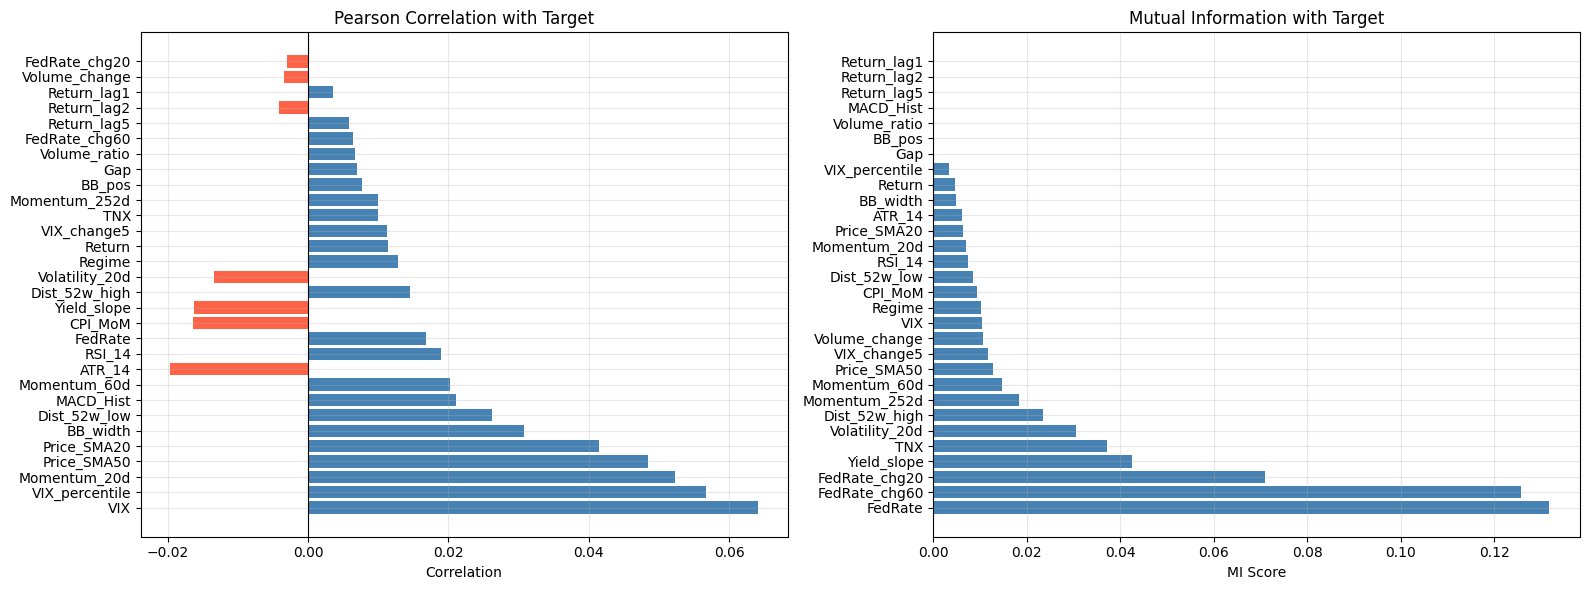

Top 5 by |Pearson|:
  VIX                   r=+0.0641
  VIX_percentile        r=+0.0568
  Momentum_20d          r=+0.0524
  Price_SMA50           r=+0.0484
  Price_SMA20           r=+0.0415

Top 5 by MI:
  FedRate               MI=0.1317
  FedRate_chg60         MI=0.1257
  FedRate_chg20         MI=0.0710
  Yield_slope           MI=0.0425
  TNX                   MI=0.0372


In [12]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

X_tr = train_scaled[FEATURE_COLS].values
y_tr = train_df[TARGET_COL].values

pearson = np.array([np.corrcoef(X_tr[:, i], y_tr)[0, 1] for i in range(len(FEATURE_COLS))])
mi      = mutual_info_classif(X_tr, y_tr, random_state=42)

p_order  = np.argsort(np.abs(pearson))[::-1]
mi_order = np.argsort(mi)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['steelblue' if v >= 0 else 'tomato' for v in pearson[p_order]]
axes[0].barh(np.array(FEATURE_COLS)[p_order], pearson[p_order], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Pearson Correlation with Target')
axes[0].set_xlabel('Correlation')
axes[0].grid(True, alpha=0.3)

axes[1].barh(np.array(FEATURE_COLS)[mi_order], mi[mi_order], color='steelblue')
axes[1].set_title('Mutual Information with Target')
axes[1].set_xlabel('MI Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Top 5 by |Pearson|:')
for i in p_order[:5]:  print(f'  {FEATURE_COLS[i]:20s}  r={pearson[i]:+.4f}')
print('\nTop 5 by MI:')
for i in mi_order[:5]: print(f'  {FEATURE_COLS[i]:20s}  MI={mi[i]:.4f}')

## 4. Model Architecture — Two-Stream LSTM

```
Sequential features (60 days × 30)  Macro snapshot (7,)
         │                                   │
      LSTM (hidden=32)               Linear(7→16) + ReLU
         │                                   │
   last hidden state (32,)          macro embedding (16,)
         └──────────── concat ───────────────┘
                           │
               Dropout(0.3) → Linear(48→1)
                           │
                        logit
```

**Why bypass the LSTM for macro features?**  
FedRate and VIX change on the scale of weeks to months. Feeding them through 60 LSTM steps alongside daily returns buries their signal in high-frequency noise. A direct shortcut to the classification head makes it trivially easy for the model to use this information.

In [13]:
class ReturnPredictor(nn.Module):
    def __init__(self, n_features, n_macro, hidden=32, dropout=0.3):
        super().__init__()
        self.lstm      = nn.LSTM(n_features, hidden, num_layers=1, batch_first=True)
        self.macro_mlp = nn.Sequential(nn.Linear(n_macro, 16), nn.ReLU())
        self.head      = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden + 16, 1))

    def forward(self, x_seq, macro):
        # x_seq : (batch, seq_len, n_features)
        # macro : (batch, n_macro)
        lstm_out, _ = self.lstm(x_seq)
        h_last      = lstm_out[:, -1, :]          # take only the last time step
        m           = self.macro_mlp(macro)
        return self.head(torch.cat([h_last, m], dim=-1)).squeeze(-1)  # raw logit

## 5. Training

### Loss
`BCEWithLogitsLoss` — numerically stable binary cross-entropy that applies sigmoid internally.

### Optimiser & scheduler
- **Adam (lr=0.001)** — adaptive per-parameter learning rates.
- **ReduceLROnPlateau** — halves the LR when validation loss stops improving for 10 epochs. Prevents overshooting a good solution without committing to a fixed schedule.

### Gradient clipping
Clips the global gradient norm to 1.0 to prevent LSTM exploding gradients.

### Early stopping
Saves the weights whenever validation loss improves. Stops if no improvement for 40 consecutive epochs.

### Multi-restart
LSTM training is sensitive to random initialisation. Running 10 independent restarts with different seeds and keeping the best validation loss result reduces the chance of reporting a lucky or unlucky run.

Device: cuda
Running 10 restarts...
  Restart  1: val_loss=0.693848  (21 epochs)
  Restart  2: val_loss=0.693839  (22 epochs)
  Restart  3: val_loss=0.697125  (22 epochs)
  Restart  4: val_loss=0.692890  (21 epochs)
  Restart  5: val_loss=0.698387  (22 epochs)
  Restart  6: val_loss=0.690929  (23 epochs)
  Restart  7: val_loss=0.694067  (23 epochs)
  Restart  8: val_loss=0.692478  (23 epochs)
  Restart  9: val_loss=0.692396  (22 epochs)
  Restart 10: val_loss=0.696325  (21 epochs)

Best restart: #6  val_loss=0.690929


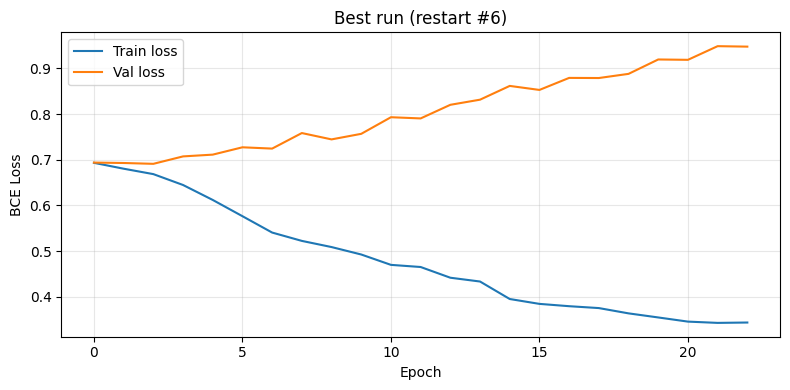

In [14]:
import joblib
import torch.optim as optim
import random

MODEL_SAVE   = '/content/drive/MyDrive/models/stage1_model.pth'
SCALER_SAVE  = '/content/drive/MyDrive/models/stage1_scaler.joblib'

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
HIDDEN_SIZE = 32
DROPOUT     = 0.3
LR          = 0.001
N_EPOCHS    = 300
PATIENCE    = 20
N_RESTARTS  = 10

print(f'Device: {DEVICE}')

loss_fn = nn.BCEWithLogitsLoss()

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def train_one_run(seed):
    set_seed(seed)
    model = ReturnPredictor(len(FEATURE_COLS), len(MACRO_COLS), HIDDEN_SIZE, DROPOUT).to(DEVICE)
    opt   = optim.Adam(model.parameters(), lr=LR)
    sch   = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=10, min_lr=1e-5)

    best_val, best_state, no_improve = float('inf'), None, 0
    t_hist, v_hist = [], []

    for epoch in range(N_EPOCHS):
        # --- train ---
        model.train()
        t_loss = 0.0
        for x, xm, y in train_loader:
            x, xm, y = x.to(DEVICE), xm.to(DEVICE), y.to(DEVICE)
            loss = loss_fn(model(x, xm), y)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            t_loss += loss.item()
        t_hist.append(t_loss / len(train_loader))

        # --- validate ---
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for x, xm, y in val_loader:
                x, xm, y = x.to(DEVICE), xm.to(DEVICE), y.to(DEVICE)
                v_loss += loss_fn(model(x, xm), y).item()
        v_loss /= len(val_loader)
        v_hist.append(v_loss)
        sch.step(v_loss)

        if v_loss < best_val:
            best_val   = v_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= PATIENCE:
            break

    return best_val, best_state, t_hist, v_hist


# Run N_RESTARTS and keep the best
best_val_overall, best_state_overall, best_run = float('inf'), None, -1
all_t, all_v = [], []

print(f'Running {N_RESTARTS} restarts...')
for i in range(N_RESTARTS):
    val, state, th, vh = train_one_run(seed=i * 17)
    all_t.append(th); all_v.append(vh)
    print(f'  Restart {i+1:2d}: val_loss={val:.6f}  ({len(th)} epochs)')
    if val < best_val_overall:
        best_val_overall, best_state_overall, best_run = val, state, i

print(f'\nBest restart: #{best_run+1}  val_loss={best_val_overall:.6f}')

# Load best weights
model = ReturnPredictor(len(FEATURE_COLS), len(MACRO_COLS), HIDDEN_SIZE, DROPOUT).to(DEVICE)
model.load_state_dict(best_state_overall)

torch.save(model.state_dict(), MODEL_SAVE)
joblib.dump(scaler, SCALER_SAVE)

# Plot loss curves for the best run
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(all_t[best_run], label='Train loss')
ax.plot(all_v[best_run], label='Val loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title(f'Best run (restart #{best_run+1})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Inference

Apply `sigmoid` to the raw logits to get probabilities in (0, 1).  
Classification threshold = **0.5**: predict up if probability > 0.5, otherwise down.

In [15]:
model.eval()

preds_list, targets_list = [], []
with torch.no_grad():
    for x, xm, y in test_loader:
        prob = torch.sigmoid(model(x.to(DEVICE), xm.to(DEVICE)))
        preds_list.append(prob.cpu().numpy())
        targets_list.append(y.numpy())

preds   = np.concatenate(preds_list)
targets = np.concatenate(targets_list)

print(f'Prob range : [{preds.min():.3f}, {preds.max():.3f}]')
print(f'Prob mean  : {preds.mean():.3f}   std: {preds.std():.3f}')

Prob range : [0.381, 0.678]
Prob mean  : 0.526   std: 0.059


## 7. Evaluation

| Metric | What it measures |
|--------|------------------|
| **AUC-ROC** | Ranking quality — probability that the model scores a random positive higher than a random negative. Threshold-independent, the primary metric. |
| **Corr** | Pearson correlation between predicted probability and true label (0/1). |
| **Baseline** | Fraction of positive samples in the test set — accuracy of a naïve "always predict up" strategy. |
| **Accuracy** | Fraction of correct predictions at threshold = 0.5. |
| **F1 Score** | Harmonic mean of precision and recall at threshold = 0.5. |
| **High-confidence subset** | Samples where the model is most decisive (prob > 0.6 or < 0.4). Should show meaningfully higher accuracy if confidence scores are calibrated. |

In [16]:
from sklearn.metrics import f1_score, roc_auc_score

true_dir = (targets > 0.5).astype(int)
pred_dir = (preds   > 0.5).astype(int)

auc      = roc_auc_score(true_dir, preds)
corr     = np.corrcoef(preds, targets)[0, 1]
baseline = true_dir.mean()
acc      = (pred_dir == true_dir).mean()
f1       = f1_score(true_dir, pred_dir)

print('===== TEST RESULTS =====')
print(f'AUC-ROC  : {auc:.4f}')
print(f'Corr     : {corr:.4f}')
print(f'Baseline : {baseline:.4f}  (naive always-up accuracy)')
print(f'Accuracy : {acc:.4f}')
print(f'F1 Score : {f1:.4f}')

# High-confidence subset — model is decisive when prob is far from 0.5
CONF = 0.6
hc_mask = (preds > CONF) | (preds < (1 - CONF))
if hc_mask.sum() > 0:
    hc_acc = (pred_dir[hc_mask] == true_dir[hc_mask]).mean()
    hc_auc = roc_auc_score(true_dir[hc_mask], preds[hc_mask])
    print(f'\n===== HIGH-CONFIDENCE SUBSET (prob >{CONF} or <{1-CONF}) =====')
    print(f'Coverage : {hc_mask.mean():.1%}  ({hc_mask.sum()} samples)')
    print(f'Accuracy : {hc_acc:.4f}')
    print(f'AUC-ROC  : {hc_auc:.4f}')

===== TEST RESULTS =====
AUC-ROC  : 0.6672
Corr     : 0.2514
Baseline : 0.5758  (naive always-up accuracy)
Accuracy : 0.6291
F1 Score : 0.7069

===== HIGH-CONFIDENCE SUBSET (prob >0.6 or <0.4) =====
Coverage : 12.2%  (101 samples)
Accuracy : 0.7525
AUC-ROC  : 0.7163


## 8. Confidence Calibration Analysis

A well-calibrated model should show **monotonically increasing accuracy** as predicted probability moves away from 0.5.  

- **Left plot**: distribution of predicted probabilities for correct vs incorrect predictions.  
  Good sign: correct predictions cluster near 0 and 1; incorrect predictions cluster near 0.5.
- **Right plot**: accuracy within each 0.1-wide probability bucket.  
  Good sign: buckets near 0 have low accuracy (correctly predicting down), buckets near 1 have high accuracy (correctly predicting up).

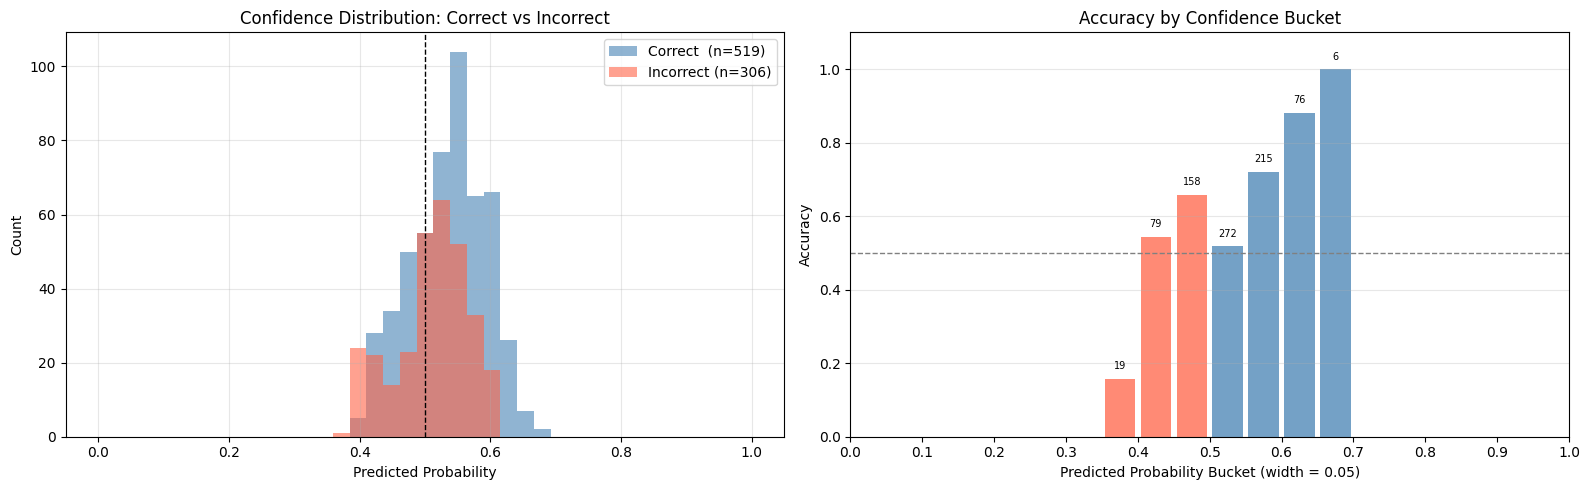

        Bucket      n  Accuracy  Bar
---------------------------------------------
  [0.35, 0.40)     19     0.158  ███
  [0.40, 0.45)     79     0.544  ██████████
  [0.45, 0.50)    158     0.658  █████████████
  [0.50, 0.55)    272     0.518  ██████████
  [0.55, 0.60)    215     0.721  ██████████████
  [0.60, 0.65)     76     0.882  █████████████████
  [0.65, 0.70)      6     1.000  ████████████████████


In [17]:
correct_mask = (pred_dir == true_dir)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Distribution: correct vs incorrect ---
bins = np.linspace(0, 1, 40)
axes[0].hist(preds[correct_mask],  bins=bins, alpha=0.6, color='steelblue', label=f'Correct  (n={correct_mask.sum()})')
axes[0].hist(preds[~correct_mask], bins=bins, alpha=0.6, color='tomato',    label=f'Incorrect (n={(~correct_mask).sum()})')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution: Correct vs Incorrect')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Accuracy by probability bucket (width = 0.05, i.e. 20 buckets) ---
BUCKET_WIDTH = 0.05
edges   = np.arange(0, 1 + BUCKET_WIDTH, BUCKET_WIDTH)
centers, accs, counts = [], [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (preds >= lo) & (preds < hi)
    if m.sum() == 0:
        continue
    centers.append((lo + hi) / 2)
    accs.append((pred_dir[m] == true_dir[m]).mean())
    counts.append(m.sum())

bar_colors = ['steelblue' if c >= 0.5 else 'tomato' for c in centers]
bars = axes[1].bar(centers, accs, width=BUCKET_WIDTH * 0.85, color=bar_colors, alpha=0.75)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)

# Annotate each bar with sample count
for bar, n in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 str(n), ha='center', va='bottom', fontsize=7)

axes[1].set_xlabel('Predicted Probability Bucket (width = 0.05)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy by Confidence Bucket')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.1)
axes[1].set_xticks(np.arange(0, 1.05, 0.1))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print table
print(f'{"Bucket":>14}  {"n":>5}  {"Accuracy":>8}  Bar')
print('-' * 45)
for c, n, a in zip(centers, counts, accs):
    lo, hi = c - BUCKET_WIDTH / 2, c + BUCKET_WIDTH / 2
    bar = '█' * int(a * 20)
    print(f'  [{lo:.2f}, {hi:.2f})  {n:5d}  {a:8.3f}  {bar}')

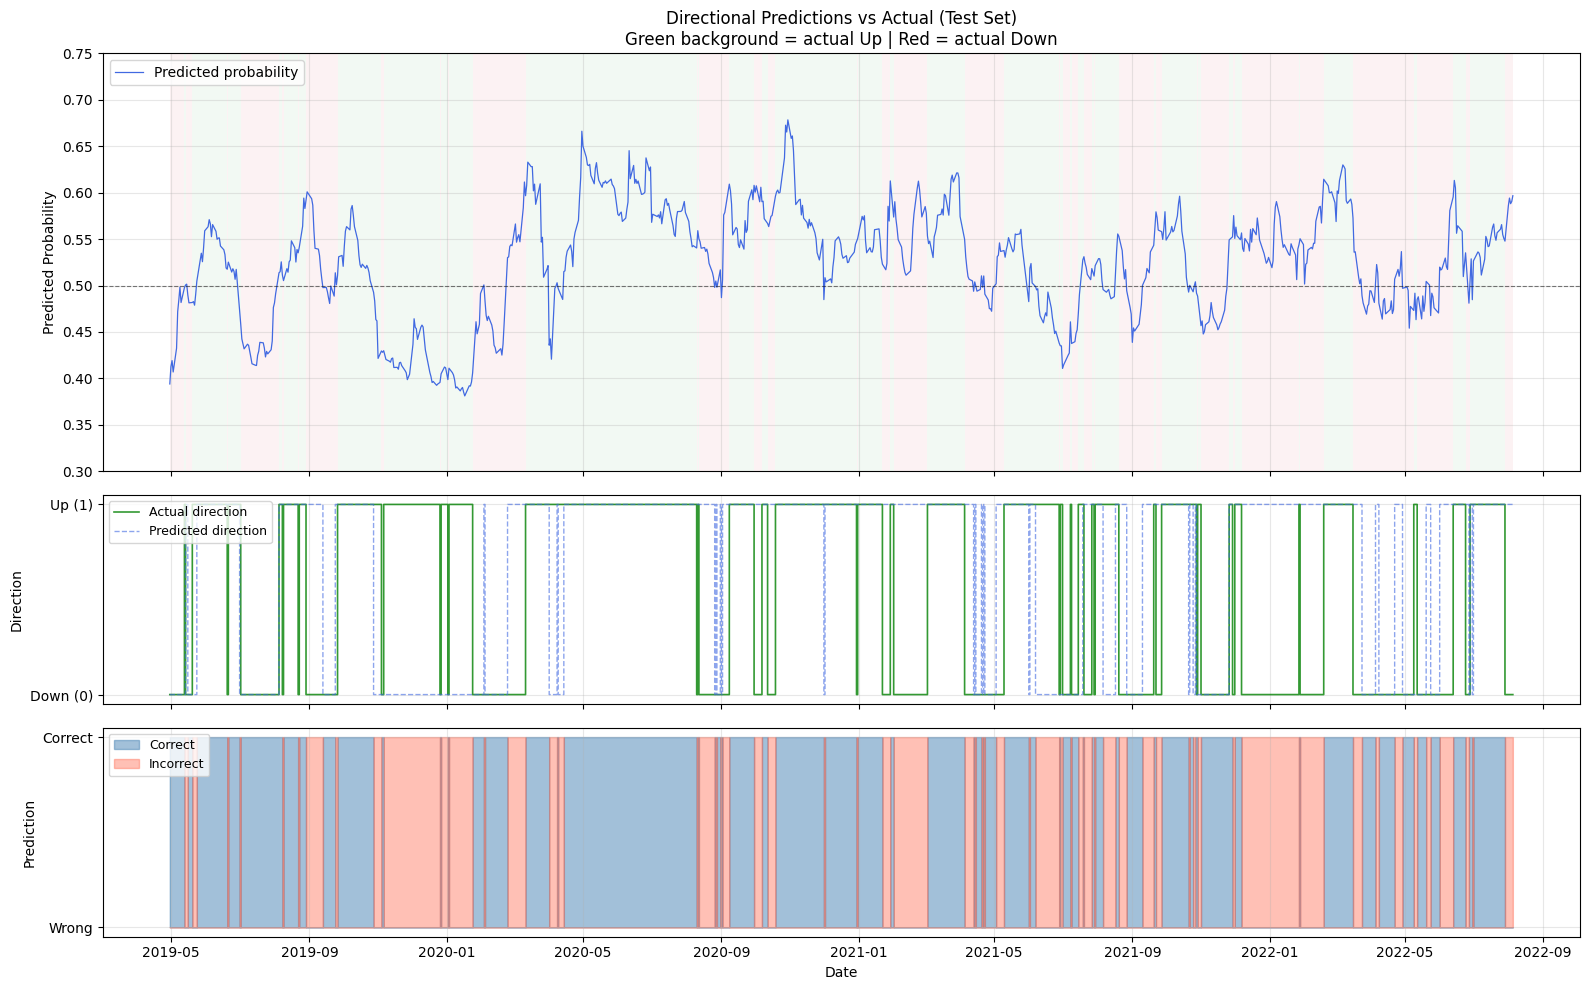

Overall accuracy : 519/825 = 62.9%
Correct Up       : 369/475 = 77.7%
Correct Down     : 150/350 = 42.9%


In [18]:

# ── Directional Predictions: Actual vs Predicted ─────────────────────────────
# Each sample's label aligns to day (s + window - 1) of test_df.
# range(0, len(test_df) - window) gives exactly len(preds) indices.
dates = pd.to_datetime(
    test_df['Date'].values[WINDOW_SIZE - 1 : WINDOW_SIZE - 1 + len(preds)]
)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1, 1]})

# --- Panel 1: predicted probability with actual direction shading ---
ax = axes[0]
ax.plot(dates, preds, color='royalblue', linewidth=0.9, label='Predicted probability')
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
for i in range(len(dates) - 1):
    color = '#d4edda' if true_dir[i] == 1 else '#f8d7da'
    ax.axvspan(dates[i], dates[i + 1], alpha=0.3, color=color, linewidth=0)
ax.set_ylabel('Predicted Probability')
ax.set_title('Directional Predictions vs Actual (Test Set)\nGreen background = actual Up | Red = actual Down')
ax.legend(loc='upper left')
ax.set_ylim(0.3, 0.75)
ax.grid(True, alpha=0.3)
ax.tick_params(labelbottom=False)

# --- Panel 2: actual vs predicted direction as step lines ---
ax2 = axes[1]
ax2.step(dates, true_dir, where='post', color='green', linewidth=1.2, alpha=0.8, label='Actual direction')
ax2.step(dates, pred_dir, where='post', color='royalblue', linewidth=1.0, alpha=0.6, linestyle='--', label='Predicted direction')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Down (0)', 'Up (1)'])
ax2.set_ylabel('Direction')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.tick_params(labelbottom=False)

# --- Panel 3: correct vs incorrect per day ---
ax3 = axes[2]
correct = (pred_dir == true_dir).astype(int)
ax3.fill_between(dates, correct,       step='post', alpha=0.5, color='steelblue', label='Correct')
ax3.fill_between(dates, 1 - correct,   step='post', alpha=0.4, color='tomato',    label='Incorrect')
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Wrong', 'Correct'])
ax3.set_ylabel('Prediction')
ax3.set_xlabel('Date')
ax3.legend(loc='upper left', fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
n_total        = len(true_dir)
n_correct      = correct.sum()
n_up_correct   = ((true_dir == 1) & (pred_dir == 1)).sum()
n_down_correct = ((true_dir == 0) & (pred_dir == 0)).sum()
print(f'Overall accuracy : {n_correct}/{n_total} = {n_correct/n_total:.1%}')
print(f'Correct Up       : {n_up_correct}/{(true_dir==1).sum()} = {n_up_correct/(true_dir==1).sum():.1%}')
print(f'Correct Down     : {n_down_correct}/{(true_dir==0).sum()} = {n_down_correct/(true_dir==0).sum():.1%}')
